In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Dataset path
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

print("Normal Path Exists:", os.path.exists(normal_path))
print("OSCC Path Exists:", os.path.exists(oscc_path))

Mounted at /content/drive
Normal Path Exists: True
OSCC Path Exists: True


In [2]:
import cv2
import numpy as np

IMG_SIZE = 160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

X_normal = np.array(normal_images)
y_normal = np.array(normal_labels)
X_oscc = np.array(oscc_images)
y_oscc = np.array(oscc_labels)

print("Normal Images:", X_normal.shape)
print("OSCC Images:", X_oscc.shape)

Normal Images: (89, 160, 160, 3)
OSCC Images: (439, 160, 160, 3)


In [3]:
from imblearn.over_sampling import SMOTE

X_combined = np.concatenate((X_normal, X_oscc), axis=0)
y_combined = np.concatenate((y_normal, y_oscc), axis=0)

# Flatten for SMOTE
X_flat = X_combined.reshape((X_combined.shape[0], -1))
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_combined)

# Reshape back
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

print("Balanced Distribution:", np.bincount(y_resampled))

Balanced Distribution: [439 439]


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)

Train: 702 Val: 88 Test: 88


In [5]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Dense

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    x = Conv2D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def CustomResNet30(input_shape=(160, 160, 3), num_classes=2):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Define the number of residual blocks per stage
    # For approximately 30 layers, we can use [3, 4, 6, 3] blocks as in ResNet34
    block_counts = [3, 4, 6, 3]
    filter_sizes = [64, 128, 256, 512]

    for filters, blocks in zip(filter_sizes, block_counts):
        for i in range(blocks):
            stride = 2 if i == 0 and filters != 64 else 1
            x = residual_block(x, filters, stride=stride)

    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


In [6]:
model = CustomResNet30()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    batch_size=32
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 80, 80,    │      9,472 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 80, 80,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 40, 40,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 40,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 40, 40,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 40,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 40, 40,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 40, 40,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        256 │ conv2d_4[0][0]  

 Total params: 21,376,130 (81.54 MB)

 Trainable params: 21,359,106 (81.48 MB)

 Non-trainable params: 17,024 (66.50 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 285s 11s/step - accuracy: 0.7129 - loss: 1.0614 - val_accuracy: 0.5341 - val_loss: 1407.3540
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 254s 12s/step - accuracy: 0.8208 - loss: 0.4136 - val_accuracy: 0.4659 - val_loss: 4.7325
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 249s 11s/step - accuracy: 0.8434 - loss: 0.3308 - val_accuracy: 0.7841 - val_loss: 0.5886
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 251s 11s/step - accuracy: 0.8383 - loss: 0.3524 - val_accuracy: 0.7614 - val_loss: 0.5608
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 261s 11s/step - accuracy: 0.8312 - loss: 0.3472 - val_accuracy: 0.5795 - val_loss: 1.1520
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 247s 11s/step - accuracy: 0.8351 - loss: 0.4097 - val_accuracy: 0.6023 - val_loss: 0.7328
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 249s 11s/step - accuracy: 0.8600 - loss: 0.3096 - val_accuracy: 0.5341 - val_loss: 1.5395
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 251s 11s/step - accuracy: 0.9124 - loss: 0.2501 - val_accuracy:

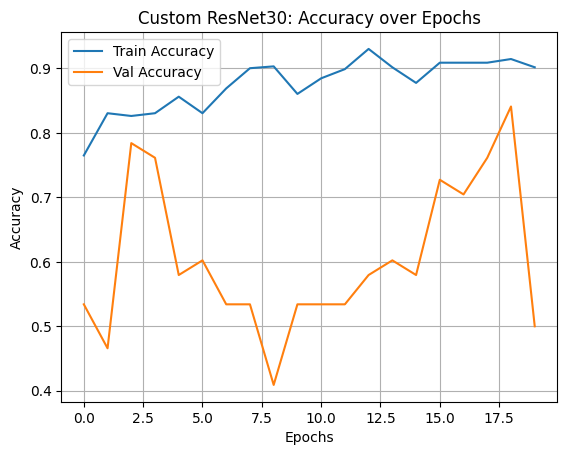

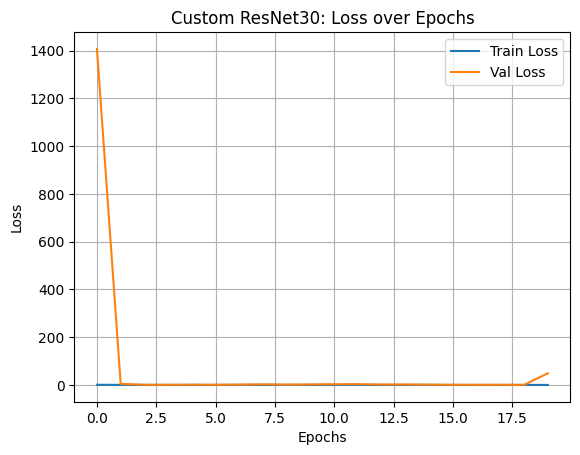

In [9]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Custom ResNet30: Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Custom ResNet30: Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4251 - loss: 75.6284
Test Accuracy: 42.05%


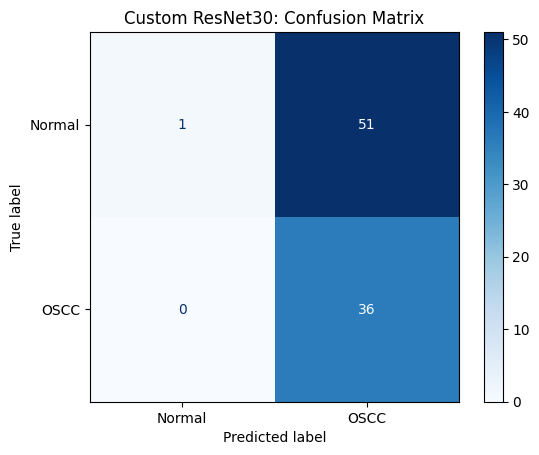


Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.02      0.04        52
        OSCC       0.41      1.00      0.59        36

    accuracy                           0.42        88
   macro avg       0.71      0.51      0.31        88
weighted avg       0.76      0.42      0.26        88



In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import numpy as np

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'OSCC'])
disp.plot(cmap='Blues')
plt.title("Custom ResNet30: Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Normal", "OSCC"]))
